# Proyecto 1 — Semana 6: Transformer desde cero

**Curso:** Deep Learning  
**Valor:** 8% de la nota del curso  
**Entrega:** Notebook ejecutado + video de 3 minutos (ver instrucciones al final)

---

## Descripcion general

Este proyecto tiene cuatro partes:

**Parte 1 (40 pts):** Implementar un Transformer Encoder desde cero con PyTorch para clasificacion de sentimientos sobre el corpus SST-2 (resenas de peliculas).

**Parte 2 (25 pts):** Implementar un Mini-GPT decoder-only desde cero, reutilizando los mismos bloques del encoder pero con mascara causal, para modelado de lenguaje sobre el mismo corpus.

**Parte 3 (15 pts):** Artifact de visualizacion interactivo que muestra los mapas de atencion del encoder y la generacion de texto del Mini-GPT.

**Parte 4 (20 pts):** Video de 3 minutos donde el grupo explica su artifact, muestra el Mini-GPT generando texto en vivo, y responde las preguntas de analisis.

## Reglas generales

- Todo el codigo de los bloques marcados debe implementarse con **tensores PyTorch puros**. No se permite `nn.MultiheadAttention`, `nn.TransformerEncoder`, ni ninguna capa de alto nivel que implemente la arquitectura por usted.
- Puede usar `nn.Parameter` y `torch.optim.Adam` para el entrenamiento.
- Puede usar `loss.backward()` y `optimizer.step()` — el backward automatico de PyTorch es valido en este proyecto.
- El corpus se descarga automaticamente desde GitHub al ejecutar el Bloque 0.
- La celda de verificacion automatica al final califica los 65 puntos de codigo.

---
## Bloque 0: Imports, corpus y vocabularios (dado, no modificar)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, random, hashlib
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

torch.manual_seed(42)
random.seed(42)
print(f'PyTorch: {torch.__version__}')


PyTorch: 2.13.0+cpu


In [2]:
# Corpus SST-2 desde GitHub
import urllib.request, random
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification'
    '/master/data/SST2/train.tsv', 'sst2_train.tsv')
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification'
    '/master/data/SST2/dev.tsv', 'sst2_dev.tsv')

def filter_data(path, min_len=3, max_len=15):
    out = []
    with open(path) as f:
        for l in f:
            parts = l.strip().split('\t')
            if len(parts) != 2: continue
            text, label = parts[0].lower(), int(parts[1])
            if min_len <= len(text.split()) <= max_len:
                out.append((text, label))
    return out

random.seed(42)
train_all = filter_data('sst2_train.tsv')
dev_all   = filter_data('sst2_dev.tsv')
random.shuffle(train_all)
TRAIN_CLS = train_all[:300]
DEV_CLS   = dev_all[:100]
GPT_TRAIN = [t for t,_ in train_all[:400]]
print(f'Clasificacion - Train: {len(TRAIN_CLS)}, Dev: {len(DEV_CLS)}')
print(f'GPT corpus: {len(GPT_TRAIN)} oraciones')
print(f'Ejemplo clasificacion: {TRAIN_CLS[0]}')
print(f'Ejemplo GPT: {GPT_TRAIN[0]}')


Clasificacion - Train: 300, Dev: 100
GPT corpus: 400 oraciones
Ejemplo clasificacion: ("the movie 's thesis elegant technology for the masses is surprisingly refreshing", 1)
Ejemplo GPT: the movie 's thesis elegant technology for the masses is surprisingly refreshing


In [3]:
# Vocabulario para clasificacion (con token CLS)
PAD, UNK, CLS = '<PAD>', '<UNK>', '<CLS>'
SPECIAL = [PAD, UNK, CLS]
words_cls = Counter()
for t,_ in TRAIN_CLS: words_cls.update(t.split())
vocab_cls = SPECIAL + [w for w,c in words_cls.most_common() if c >= 2]
w2i_cls = {w:i for i,w in enumerate(vocab_cls)}
i2w_cls = {i:w for w,i in w2i_cls.items()}
V_CLS = len(vocab_cls)
MAX_LEN_CLS = 16  # CLS + hasta 15 tokens

# Vocabulario para GPT (con BOS y EOS)
BOS, EOS, PAD_G, UNK_G = '<BOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL_G = [PAD_G, UNK_G, BOS, EOS]
words_gpt = Counter()
for t in GPT_TRAIN: words_gpt.update(t.split())
vocab_gpt = SPECIAL_G + [w for w,c in words_gpt.most_common() if c >= 2]
w2i_gpt = {w:i for i,w in enumerate(vocab_gpt)}
i2w_gpt = {i:w for w,i in w2i_gpt.items()}
V_GPT = len(vocab_gpt)
MAX_LEN_GPT = 14  # BOS + hasta 12 tokens + EOS

print(f'Vocab clasificacion: {V_CLS}, MAX_LEN: {MAX_LEN_CLS}')
print(f'Vocab GPT: {V_GPT}, MAX_LEN: {MAX_LEN_GPT}')

def tokenize_cls(text, max_len=MAX_LEN_CLS):
    toks = [CLS] + [w if w in w2i_cls else UNK for w in text.split()[:max_len-1]]
    idxs = [w2i_cls[t] for t in toks]
    mask = [True]*len(idxs) + [False]*(max_len-len(idxs))
    while len(idxs) < max_len: idxs.append(w2i_cls[PAD])
    return torch.tensor(idxs[:max_len]), torch.tensor(mask[:max_len])

def tokenize_gpt(text, max_len=MAX_LEN_GPT):
    toks = [BOS]+[w if w in w2i_gpt else UNK_G for w in text.split()[:max_len-2]]+[EOS]
    idxs = [w2i_gpt[t] for t in toks]
    while len(idxs) < max_len: idxs.append(w2i_gpt[PAD_G])
    return torch.tensor(idxs[:max_len])

# Verificacion de tokenizacion
idxs_test, mask_test = tokenize_cls(TRAIN_CLS[0][0])
print(f'Ejemplo tokenizado: {[i2w_cls[i.item()] for i in idxs_test[:8]]}')
print(f'Mascara: {mask_test[:8].tolist()}')


Vocab clasificacion: 328, MAX_LEN: 16
Vocab GPT: 432, MAX_LEN: 14
Ejemplo tokenizado: ['<CLS>', 'the', 'movie', "'s", '<UNK>', 'elegant', '<UNK>', 'for']
Mascara: [True, True, True, True, True, True, True, True]


In [4]:
# Dimensiones del modelo (fijas para autograder)
D_MODEL = 32   # dimension central de la arquitectura
D_FF    = 64   # dimension interna del FFN
N_HEADS = 2    # numero de cabezas de atencion
D_K     = D_MODEL // N_HEADS  # dimension por cabeza = 16

# Positional encoding (dado, no modificar)
def make_positional_encoding(max_len, d_model):
    """
    Genera la matriz de positional encoding de Vaswani et al. 2017.
    PE(t, 2i)   = sin(t / 10000^(2i/d_model))
    PE(t, 2i+1) = cos(t / 10000^(2i/d_model))

    Parametros
    ----------
    max_len : int, largo maximo de secuencia
    d_model : int, dimension del modelo

    Retorna
    -------
    pe : torch.Tensor de forma (max_len, d_model)
    """
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(
        torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

PE_CLS = make_positional_encoding(MAX_LEN_CLS, D_MODEL)
PE_GPT = make_positional_encoding(MAX_LEN_GPT, D_MODEL)
print(f'PE_CLS: {PE_CLS.shape}, PE_GPT: {PE_GPT.shape}')

# Mascara causal para GPT (triangular superior = True = enmascarado)
CAUSAL_MASK = torch.triu(torch.ones(MAX_LEN_GPT, MAX_LEN_GPT), diagonal=1).bool()
print(f'CAUSAL_MASK shape: {CAUSAL_MASK.shape}')
print('Primeras 4 filas de la mascara causal:')
print(CAUSAL_MASK[:4, :6].int())


PE_CLS: torch.Size([16, 32]), PE_GPT: torch.Size([14, 32])
CAUSAL_MASK shape: torch.Size([14, 14])
Primeras 4 filas de la mascara causal:
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1]], dtype=torch.int32)


---
## Parte 1: Transformer Encoder para clasificacion de sentimientos

Implemente el encoder Transformer completo como una clase `nn.Module`. El modelo usa un token especial `[CLS]` en la primera posicion: su representacion despues del bloque encoder se usa para clasificar la oracion como positiva (1) o negativa (0).

**Arquitectura:**
```
texto -> tokenize_cls -> E[idxs] + PE  ->  [Multi-Head Self-Attention]
                                            [Add & LayerNorm]
                                            [Feed-Forward por posicion]
                                            [Add & LayerNorm]
                                        ->  representacion CLS -> W_cls -> logits
```

**Parametros que debe declarar en `__init__` como `nn.Parameter`:**

| Parametro | Forma | Descripcion |
|---|---|---|
| `E` | $(V_{cls}, d_{model})$ | Matriz de embeddings |
| `WQ`, `WK`, `WV` | $(d_{model}, d_{model})$ | Proyecciones de atencion |
| `WO` | $(d_{model}, d_{model})$ | Proyeccion de salida multi-head |
| `gamma1`, `beta1` | $(d_{model},)$ | LayerNorm 1 |
| `W1` | $(d_{model}, d_{ff})$ | FFN capa 1 |
| `bias1` | $(d_{ff},)$ | Bias FFN capa 1 |
| `W2` | $(d_{ff}, d_{model})$ | FFN capa 2 |
| `bias2` | $(d_{model},)$ | Bias FFN capa 2 |
| `gamma2`, `beta2` | $(d_{model},)$ | LayerNorm 2 |
| `Wcls` | $(d_{model}, 2)$ | Clasificador sobre token CLS |
| `bcls` | $(2,)$ | Bias clasificador |

In [5]:
def layer_norm(x, gamma, beta, eps=1e-5):
    """
    Layer Normalization sobre la ultima dimension.

    Parametros
    ----------
    x     : Tensor de forma (..., d_model)
    gamma : Tensor de forma (d_model,) — escala aprendible
    beta  : Tensor de forma (d_model,) — desplazamiento aprendible
    eps   : float, estabilidad numerica

    Retorna
    -------
    Tensor de la misma forma que x, normalizado por media y std
    sobre la dimension d_model.
    """
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)
    x_norm = (x - mean) / torch.sqrt(var + eps)
    return gamma * x_norm + beta

# Prueba rapida de layer_norm
_x = torch.randn(16, D_MODEL)
_g = torch.ones(D_MODEL); _b = torch.zeros(D_MODEL)
_out = layer_norm(_x, _g, _b)
print(f'layer_norm output shape: {_out.shape}')
print(f'Media por fila (debe ser ~0): {_out.mean(-1).abs().max().item():.6f}')
print(f'Std por fila (debe ser ~1):  {_out.std(-1).mean().item():.4f}')


layer_norm output shape: torch.Size([16, 32])
Media por fila (debe ser ~0): 0.000000
Std por fila (debe ser ~1):  1.0160


In [6]:
class TransformerEncoder(nn.Module):
    """
    Transformer Encoder de un bloque para clasificacion de sentimientos.
    Usa el token [CLS] en la posicion 0 para la clasificacion final.
    """
    def __init__(self, V, d_model, d_ff, n_heads, d_k):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_k

        self.E = nn.Parameter(torch.randn(V, d_model) * 0.1)

        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * 0.1)

        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))

        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * 0.1)
        self.bias1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * 0.1)
        self.bias2 = nn.Parameter(torch.zeros(d_model))

        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))

        self.Wcls = nn.Parameter(torch.randn(d_model, 2) * 0.1)
        self.bcls = nn.Parameter(torch.zeros(2))

    def multi_head_attention(self, x, pad_mask):
        """
        Multi-head self-attention sobre la secuencia x.

        Parametros
        ----------
        x        : Tensor (T, d_model) — secuencia con embeddings + PE
        pad_mask : Tensor bool (T,) — True en posiciones validas, False en PAD

        Retorna
        -------
        out      : Tensor (T, d_model)
        attn_w   : Tensor (n_heads, T, T) — pesos de atencion (para visualizacion)

        Pasos:
        1. Proyectar x con WQ, WK, WV: forma (T, d_model)
        2. Reshape a (n_heads, T, d_k) para procesar en paralelo
        3. Calcular scores = Q @ K^T / sqrt(d_k): forma (n_heads, T, T)
        4. Enmascarar posiciones PAD con -inf antes del softmax
        5. Aplicar softmax sobre la ultima dimension
        6. Calcular out = attn_w @ V: forma (n_heads, T, d_k)
        7. Reshape y proyectar con WO: forma (T, d_model)
        """
        T = x.shape[0]

        Q = x @ self.WQ
        K = x @ self.WK
        V = x @ self.WV

        Q = Q.view(T, self.n_heads, self.d_k).transpose(0, 1)  # (n_heads, T, d_k)
        K = K.view(T, self.n_heads, self.d_k).transpose(0, 1)
        V = V.view(T, self.n_heads, self.d_k).transpose(0, 1)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (n_heads, T, T)

        key_pad_mask = (~pad_mask).view(1, 1, T)  # True donde hay que enmascarar
        scores = scores.masked_fill(key_pad_mask, float('-inf'))

        attn_w = F.softmax(scores, dim=-1)  # (n_heads, T, T)

        out = attn_w @ V  # (n_heads, T, d_k)
        out = out.transpose(0, 1).contiguous().view(T, self.d_model)  # (T, d_model)
        out = out @ self.WO

        return out, attn_w

    def feed_forward(self, x):
        """
        Red feed-forward aplicada por posicion.

        Parametros
        ----------
        x : Tensor (T, d_model)

        Retorna
        -------
        Tensor (T, d_model)

        Formula: FFN(x) = ReLU(x W1 + b1) W2 + b2
        """
        h = F.relu(x @ self.W1 + self.bias1)
        return h @ self.W2 + self.bias2

    def forward(self, text, return_attn=False):
        """
        Forward pass completo del encoder.

        Parametros
        ----------
        text        : str — oracion de entrada
        return_attn : bool — si True, tambien retorna los pesos de atencion

        Retorna
        -------
        logits : Tensor (2,) — scores para [negativo, positivo]
        attn_w : Tensor (n_heads, T, T) — solo si return_attn=True

        Pasos:
        1. tokenize_cls(text) -> idxs (T,), mask (T,)
        2. Embedding + PE: E[idxs] + PE_CLS -> x (T, d_model)
        3. Multi-head self-attention -> att_out (T, d_model)
        4. Add & LayerNorm: layer_norm(x + att_out, gamma1, beta1)
        5. Feed-forward -> ff_out (T, d_model)
        6. Add & LayerNorm: layer_norm(x2 + ff_out, gamma2, beta2)
        7. Tomar representacion del token CLS: x3[0] (d_model,)
        8. Clasificar: x3[0] @ Wcls + bcls -> logits (2,)
        """
        idxs, mask = tokenize_cls(text)
        T = idxs.shape[0]
        x = self.E[idxs] + PE_CLS[:T]

        att_out, attn_w = self.multi_head_attention(x, mask)
        x2 = layer_norm(x + att_out, self.gamma1, self.beta1)

        ff_out = self.feed_forward(x2)
        x3 = layer_norm(x2 + ff_out, self.gamma2, self.beta2)

        cls_repr = x3[0]
        logits = cls_repr @ self.Wcls + self.bcls

        if return_attn:
            return logits, attn_w
        return logits


### Verificacion Parte 1A: forward pass y shapes

Antes de entrenar, verificar que el forward produce las formas correctas.

In [7]:
torch.manual_seed(42)
enc_model = TransformerEncoder(V_CLS, D_MODEL, D_FF, N_HEADS, D_K)

# Test forward en el primer ejemplo
text_test, label_test = TRAIN_CLS[0]
logits_test, attn_test = enc_model(text_test, return_attn=True)

print(f'Texto: "{text_test}"')
print(f'Label: {label_test}')
print(f'logits shape: {logits_test.shape}  (esperado: torch.Size([2]))')
print(f'logits: {logits_test.detach()}')
print(f'attn_w shape: {attn_test.shape}  (esperado: torch.Size([{N_HEADS}, {MAX_LEN_CLS}, {MAX_LEN_CLS}]))')

# Verificar que los attention weights suman 1 por fila
row_sums = attn_test[0].sum(-1)
print(f'Suma por fila head 0 (primeras 4, debe ser ~1.0): {row_sums[:4].detach()}')

# Loss inicial
loss_test = F.cross_entropy(logits_test.unsqueeze(0), torch.tensor([label_test]))
print(f'Loss inicial (esperado ~0.69 = log(2)): {loss_test.item():.4f}')


Texto: "the movie 's thesis elegant technology for the masses is surprisingly refreshing"
Label: 1
logits shape: torch.Size([2])  (esperado: torch.Size([2]))
logits: tensor([ 0.3503, -0.8587])
attn_w shape: torch.Size([2, 16, 16])  (esperado: torch.Size([2, 16, 16]))
Suma por fila head 0 (primeras 4, debe ser ~1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000])
Loss inicial (esperado ~0.69 = log(2)): 1.4702


### Entrenamiento del encoder

Epoch  2: loss=0.7080, train_acc=51.67%


Epoch  4: loss=0.6065, train_acc=67.67%


Epoch  6: loss=0.2138, train_acc=93.00%


Epoch  8: loss=0.0909, train_acc=96.67%


Epoch 10: loss=0.0511, train_acc=98.33%


...

Epoch 18: loss=0.0264, train_acc=98.67%


Epoch 20: loss=0.0231, train_acc=98.33%


Epoch 22: loss=0.2004, train_acc=94.00%


Epoch 24: loss=0.0254, train_acc=99.33%


Dev accuracy: 64.00%


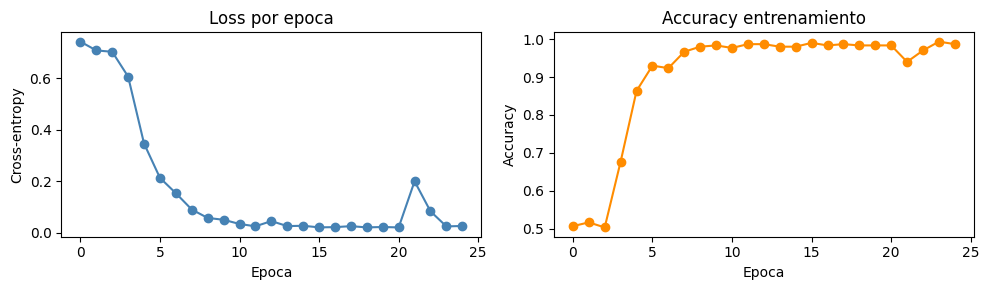

In [8]:
torch.manual_seed(42)
enc_model = TransformerEncoder(V_CLS, D_MODEL, D_FF, N_HEADS, D_K)
optimizer_enc = torch.optim.Adam(enc_model.parameters(), lr=1e-3)

history_enc = []
for epoch in range(25):
    random.shuffle(TRAIN_CLS)
    total_loss = 0; correct = 0
    enc_model.train()
    for text, label in TRAIN_CLS:
        optimizer_enc.zero_grad()
        logits = enc_model(text)
        loss = F.cross_entropy(logits.unsqueeze(0), torch.tensor([label]))
        loss.backward()
        optimizer_enc.step()
        total_loss += loss.item()
        with torch.no_grad():
            if logits.argmax().item() == label: correct += 1
    avg_loss = total_loss / len(TRAIN_CLS)
    train_acc = correct / len(TRAIN_CLS)
    history_enc.append((avg_loss, train_acc))
    if (epoch+1) % 2 == 0:
        print(f'Epoch {epoch+1:2d}: loss={avg_loss:.4f}, train_acc={train_acc:.2%}')

# Evaluacion en dev
enc_model.eval()
correct_dev = 0
for text, label in DEV_CLS:
    with torch.no_grad():
        logits, _ = enc_model(text, return_attn=True)
        if logits.argmax().item() == label: correct_dev += 1
dev_acc = correct_dev / len(DEV_CLS)
print(f'Dev accuracy: {dev_acc:.2%}')

# Grafica de convergencia
losses = [h[0] for h in history_enc]
accs   = [h[1] for h in history_enc]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(losses, 'o-', color='steelblue'); ax1.set_title('Loss por epoca')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Cross-entropy')
ax2.plot(accs, 'o-', color='darkorange'); ax2.set_title('Accuracy entrenamiento')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Accuracy')
plt.tight_layout(); plt.savefig('convergencia_encoder.png', dpi=110)
plt.show()


### Verificacion Parte 1B: convergencia

In [9]:
# VERIFICACION PARTE 1
_resultados = {}
try:
    assert dev_acc >= 0.60, \
        f'Dev accuracy {dev_acc:.2%} < 60%. Revise su implementacion o entrene mas epocas.'
    assert all(losses[i] > losses[i+1] for i in range(min(4, len(losses)-1))), \
        'La loss no decrece en las primeras epocas. Revise el forward o el optimizador.'
    _resultados['parte1'] = True
    print(f'PARTE 1: CORRECTO  (dev_acc={dev_acc:.2%})')
except AssertionError as e:
    _resultados['parte1'] = False
    print(f'PARTE 1: INCORRECTO\n  {e}')


PARTE 1: CORRECTO  (dev_acc=64.00%)


---
## Parte 2: Mini-GPT decoder-only

Implemente un Transformer decoder-only para modelado de lenguaje. El modelo aprende a predecir el siguiente token dado el contexto previo.

**La diferencia clave con el encoder:** la mascara causal. En lugar de que cada token atienda a todos los demas, cada token solo puede atender a los tokens en posiciones anteriores o iguales a la suya.

**Conexion con la Semana 5:** la mascara causal que aplica aqui es exactamente la misma que describimos en el decoder del seq2seq. La diferencia es que aqui no hay cross-attention: el modelo solo tiene self-attention con mascara.

**Reutilize** `layer_norm` y la logica de `multi_head_attention` de la Parte 1. Solo necesita modificar:
1. Agregar la mascara causal en el calculo de scores
2. Cambiar el clasificador CLS por una proyeccion al vocabulario completo
3. Cambiar el objetivo de clasificacion por prediccion del siguiente token

**Parametros del MiniGPT:**

| Parametro | Forma | Descripcion |
|---|---|---|
| `E` | $(V_{gpt}, d_{model})$ | Embeddings GPT |
| `WQ`, `WK`, `WV`, `WO` | $(d_{model}, d_{model})$ | Atencion con mascara causal |
| `gamma1`, `beta1`, `gamma2`, `beta2` | $(d_{model},)$ | LayerNorm |
| `W1`, `bias1`, `W2`, `bias2` | igual que encoder | FFN |
| `Wlm` | $(d_{model}, V_{gpt})$ | Proyeccion al vocabulario (Language Model head) |
| `blm` | $(V_{gpt},)$ | Bias proyeccion |

In [10]:
class MiniGPT(nn.Module):
    """
    Transformer decoder-only para modelado de lenguaje.
    Usa mascara causal: cada token solo atiende a tokens anteriores.
    """
    def __init__(self, V, d_model, d_ff, n_heads, d_k):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_k
        self.V = V

        # =====================
        # SU CODIGO AQUI
        # Declare todos los parametros como nn.Parameter
        # =====================
        pass

    def masked_self_attention(self, x):
        """
        Self-attention con mascara causal.

        Parametros
        ----------
        x : Tensor (T, d_model)

        Retorna
        -------
        out    : Tensor (T, d_model)
        attn_w : Tensor (n_heads, T, T)

        DIFERENCIA con el encoder:
        - No hay mascara de padding (todos los tokens son validos hasta EOS)
        - Aplicar CAUSAL_MASK: antes del softmax, sumar -inf donde
          CAUSAL_MASK[:T, :T] es True (posiciones futuras)
        """
        T = x.shape[0]
        # =====================
        # SU CODIGO AQUI
        # =====================
        pass

    def forward_all(self, idxs):
        """
        Forward sobre una secuencia de indices.

        Parametros
        ----------
        idxs : Tensor (T,) de indices del vocabulario GPT

        Retorna
        -------
        logits : Tensor (T, V_gpt) — scores sobre vocabulario en cada posicion
        attn_w : Tensor (n_heads, T, T)

        Pasos:
        1. Embedding + PE: E[idxs] + PE_GPT[:T]
        2. Masked self-attention -> att_out
        3. Add & LayerNorm
        4. Feed-forward -> ff_out
        5. Add & LayerNorm
        6. Proyectar al vocabulario: x3 @ Wlm + blm
        """
        T = len(idxs)
        # =====================
        # SU CODIGO AQUI
        # =====================
        pass

    def forward(self, text):
        """
        Calcula la loss de language modeling para una oracion.

        La loss es la cross-entropy promedio entre:
        - Input:  tokens en posicion 0..T-2  (lo que el modelo ve)
        - Target: tokens en posicion 1..T-1  (lo que debe predecir)

        Los tokens PAD en el target se ignoran con ignore_index.
        """
        idxs = tokenize_gpt(text)
        logits, _ = self.forward_all(idxs)
        pad_idx = w2i_gpt[PAD_G]
        # =====================
        # SU CODIGO AQUI
        # loss = F.cross_entropy(logits[:-1], idxs[1:], ignore_index=pad_idx)
        # =====================
        pass

    @torch.no_grad()
    def generate(self, seed_text, max_new=8, temperature=0.9):
        """
        Generacion autoregresiva: dado un texto semilla, genera max_new tokens nuevos.

        Parametros
        ----------
        seed_text   : str — texto de inicio
        max_new     : int — maximo de tokens nuevos a generar
        temperature : float — temperatura del muestreo (mayor = mas creativo)

        Retorna
        -------
        str — texto generado completo (semilla + tokens nuevos)

        Algoritmo:
        1. Tokenizar el texto actual
        2. Forward -> logits (T, V)
        3. Tomar logits en la ultima posicion valida
        4. Dividir por temperature y aplicar softmax
        5. Muestrear con torch.multinomial
        6. Agregar la nueva palabra y repetir
        7. Detener si se genera EOS o PAD
        """
        self.eval()
        words = seed_text.split()
        for _ in range(max_new):
            cur = ' '.join(words)
            idxs = tokenize_gpt(cur)
            logits, _ = self.forward_all(idxs)
            n_valid = min(len(words) + 1, MAX_LEN_GPT - 1)
            next_logits = logits[n_valid - 1] / temperature
            # =====================
            # SU CODIGO AQUI
            # No generar PAD_G ni BOS (poner -inf en esos indices)
            # Muestrear con torch.multinomial
            # =====================
            pass
        return ' '.join(words)


### Verificacion Parte 2A: mascara causal

In [11]:
torch.manual_seed(7)
gpt_model = MiniGPT(V_GPT, D_MODEL, D_FF, N_HEADS, D_K)

# Verificar que la mascara causal funciona
idxs_test = tokenize_gpt(GPT_TRAIN[0])
logits_test, attn_test = gpt_model.forward_all(idxs_test)

print(f'logits shape: {logits_test.shape}  (esperado: [{MAX_LEN_GPT}, {V_GPT}])')
print(f'attn_w shape: {attn_test.shape}  (esperado: [{N_HEADS}, {MAX_LEN_GPT}, {MAX_LEN_GPT}])')

# Verificar triangulo superior = 0 (mascara causal correcta)
print('\nVerificacion mascara causal (triangulo superior debe ser 0):')
print(f'  Head0 fila 0: {attn_test[0,0,:4].detach()}  (solo pos 0 valida)')
print(f'  Head0 fila 1: {attn_test[0,1,:4].detach()}  (pos 0,1 validas)')
print(f'  Head0 fila 2: {attn_test[0,2,:4].detach()}  (pos 0,1,2 validas)')

# La mascara es correcta si el triangulo superior (j>i) es exactamente 0
upper_triangle = attn_test[:, :3, 3:]  # posiciones futuras para filas 0,1,2
print(f'\nValores en posiciones futuras (deben ser 0): {upper_triangle.abs().max().item():.6f}')


TypeError: cannot unpack non-iterable NoneType object

### Entrenamiento del Mini-GPT

In [12]:
torch.manual_seed(7)
gpt_model = MiniGPT(V_GPT, D_MODEL, D_FF, N_HEADS, D_K)
optimizer_gpt = torch.optim.Adam(gpt_model.parameters(), lr=1e-3)

history_gpt = []
for epoch in range(10):
    random.shuffle(GPT_TRAIN)
    total_loss = 0
    gpt_model.train()
    for text in GPT_TRAIN:
        optimizer_gpt.zero_grad()
        loss = gpt_model(text)
        loss.backward()
        optimizer_gpt.step()
        total_loss += loss.item()
    avg = total_loss / len(GPT_TRAIN)
    history_gpt.append(avg)
    if (epoch+1) % 2 == 0:
        print(f'Epoch {epoch+1:2d}: loss={avg:.4f}')

# Grafica de convergencia
plt.figure(figsize=(6, 3))
plt.plot(history_gpt, 'o-', color='darkorange')
plt.title('Mini-GPT: Loss por epoca'); plt.xlabel('Epoca'); plt.ylabel('CE Loss')
plt.tight_layout(); plt.savefig('convergencia_gpt.png', dpi=110)
plt.show()

# Generacion de texto
gpt_model.eval()
print('\nGeneracion de texto con temperatura 0.8:')
for seed in ['the film', 'a surprisingly', 'not', 'the story']:
    gen = gpt_model.generate(seed, max_new=6, temperature=0.8)
    print(f'  "{seed}" -> "{gen}"')


ValueError: optimizer got an empty parameter list

### Verificacion Parte 2B: convergencia GPT

In [13]:
try:
    assert len(history_gpt) >= 5, 'Entrene al menos 5 epocas.'
    assert all(history_gpt[i] > history_gpt[i+1] for i in range(4)), \
        f'La loss GPT no decrece. Revise la mascara causal y el calculo de la loss.'
    assert history_gpt[-1] < history_gpt[0] * 0.85, \
        f'La loss final {history_gpt[-1]:.4f} debe ser < 85% de la inicial {history_gpt[0]:.4f}.'
    _resultados['parte2'] = True
    print(f'PARTE 2: CORRECTO  (loss {history_gpt[0]:.4f} -> {history_gpt[-1]:.4f})')
except AssertionError as e:
    _resultados['parte2'] = False
    print(f'PARTE 2: INCORRECTO\n  {e}')


NameError: name 'history_gpt' is not defined

---
## Parte 3: Artifact de visualizacion interactivo

Cree un artifact en Claude.ai que integre las dos partes anteriores en una interfaz visual interactiva. El artifact debe permitir:

**Panel 1 — Analisis de sentimiento:**
- Campo de texto para ingresar una oracion
- Boton 'Analizar'
- Mostrar la prediccion (POSITIVO / NEGATIVO) con porcentaje de confianza
- Mostrar el mapa de atencion de cada cabeza como heatmap con los tokens en los ejes

**Panel 2 — Generacion de texto:**
- Campo de texto para ingresar el texto semilla
- Slider para la temperatura (0.5 a 1.5)
- Boton 'Generar'
- Mostrar el texto generado y el mapa de atencion causal

**Requisito tecnico:** el artifact debe correr los pesos entrenados en este notebook. La forma mas sencilla es exportar los pesos como JSON y cargarlos en el artifact.

### Instrucciones para exportar los pesos

Ejecute la siguiente celda para generar el JSON de pesos que usara en su artifact.

In [14]:
import json

def export_weights(model, vocab, i2w, model_type='encoder'):
    """
    Exporta los pesos del modelo a un diccionario JSON-serializable.
    Los tensores se convierten a listas de Python.
    """
    weights = {}
    for name, param in model.named_parameters():
        weights[name] = param.detach().numpy().tolist()
    return {
        'model_type': model_type,
        'weights': weights,
        'vocab': vocab,
        'i2w': {str(k): v for k, v in i2w.items()},
        'd_model': D_MODEL, 'd_ff': D_FF,
        'n_heads': N_HEADS, 'd_k': D_K,
    }

# Exportar pesos del encoder
enc_weights = export_weights(enc_model, vocab_cls, i2w_cls, 'encoder')
with open('encoder_weights.json', 'w') as f:
    json.dump(enc_weights, f)
print(f'Encoder weights exportados: {len(enc_weights["weights"])} tensores')

# Exportar pesos del GPT
gpt_weights = export_weights(gpt_model, vocab_gpt, i2w_gpt, 'gpt')
with open('gpt_weights.json', 'w') as f:
    json.dump(gpt_weights, f)
print(f'GPT weights exportados: {len(gpt_weights["weights"])} tensores')
print('\nUse estos archivos JSON en su artifact de Claude.ai.')


Encoder weights exportados: 15 tensores
GPT weights exportados: 0 tensores

Use estos archivos JSON en su artifact de Claude.ai.


### Descripcion del artifact

Describa brevemente su artifact aqui. Incluya:
- URL del artifact (si es publico) o capturas de pantalla
- Descripcion de la interfaz
- Ejemplo de una oracion positiva y una negativa con sus mapas de atencion
- Ejemplo de generacion de texto con dos temperaturas distintas

*[Su descripcion aqui]*

---
## Parte 4: Preguntas de analisis

Responda las siguientes preguntas antes del video. Durante el video se les pedira explicar **una de las tres preguntas** que el profesor seleccionara en el momento de la presentacion.

---

### Pregunta 1 (video + escrita)

En su implementacion del `TransformerEncoder`, el token `[CLS]` recibe atencion de todos los tokens de la secuencia y su representacion final se usa para clasificar.

a) Trace matematicamente como fluye la informacion desde el token 'surprisingly' hasta la representacion final del token `[CLS]` a traves del mecanismo de multi-head attention. Identifique explicitamente que operaciones matriciales participan y que rol juega cada una en ese flujo.

b) En su modelo entrenado, observe los mapas de atencion para una oracion positiva y una negativa. ¿Que diferencias observa en como el token `[CLS]` distribuye su atencion sobre los tokens de la oracion? ¿Tiene alguna interpretacion sobre que tokens resultan mas informativos para la clasificacion?

c) BERT usa 12 capas de encoder apiladas. Su modelo usa solo 1. Sin implementarlo, explique matematicamente que informacion adicional podria capturar la segunda capa que la primera no puede, dado que la segunda recibe representaciones ya contextualizadas por la primera.

**Su respuesta a la Pregunta 2:**

a) Sea $s$ la posición del token `surprisingly` y $0$ la posición del token `[CLS]`.

El flujo de información desde `surprisingly` hasta `[CLS]` ocurre principalmente mediante el mecanismo de **multi-head attention**.

#### 1. Embedding y posición

Primero, cada token se convierte en un vector que combina su embedding con su información posicional:

$$
x_s = E[\text{idx}_s] + PE[s]
$$

$$
x_0 = E[\text{idx}_0] + PE[0]
$$

Aquí:

- $E$ contiene los embeddings de los tokens.
- $PE$ agrega información sobre la posición de cada token.
- $x_s$ representa inicialmente a `surprisingly`.
- $x_0$ representa inicialmente a `[CLS]`.

La información posicional es necesaria porque el mecanismo de atención por sí solo no conoce el orden de las palabras.

#### 2. Proyecciones `Q`, `K` y `V`

Para cada cabeza de atención $h$, se generan las matrices de **queries**, **keys** y **values** mediante proyecciones lineales:

$$
Q_0^h = (x_0 W_Q)^h
$$

$$
K_s^h = (x_s W_K)^h
$$

$$
V_s^h = (x_s W_V)^h
$$

Cada una tiene un papel diferente:

- $Q_0^h$ representa **qué información está buscando `[CLS]`**.
- $K_s^h$ representa **qué características ofrece `surprisingly` para ser encontrado**.
- $V_s^h$ contiene **la información de `surprisingly` que será transmitida si recibe atención**.

Por lo tanto, `surprisingly` participa tanto mediante su key $K_s^h$ como mediante su value $V_s^h$.

#### 3. Score de atención

Para saber cuánto debe atender `[CLS]` a `surprisingly`, se calcula la compatibilidad entre su query y la key de `surprisingly`:

$$
score_{0,s}^h =
\frac{Q_0^h (K_s^h)^T}{\sqrt{d_k}}
$$

El producto punto mide qué tan compatibles son ambos vectores.

Un score alto significa que, para esa cabeza, `surprisingly` contiene información relevante para lo que `[CLS]` está buscando.

La división entre $\sqrt{d_k}$ evita que los productos punto crezcan demasiado cuando aumenta la dimensión de los vectores.

#### 4. Softmax

Después se calculan los scores de `[CLS]` con **todos los tokens de la secuencia** y se aplica softmax:

$$
\alpha_{0,s}^h =
\frac{\exp(score_{0,s}^h)}
{\sum_j \exp(score_{0,j}^h)}
$$

Este valor corresponde al peso de atención que `[CLS]` asigna a `surprisingly`.

En nuestra implementación, este peso aparece en:

`attn_w[h, 0, s]`

Si el valor es alto, `[CLS]` presta mucha atención a `surprisingly`. Si es cercano a cero, su influencia directa será pequeña.

#### 5. Suma ponderada de los values

La salida de `[CLS]` para cada cabeza se calcula como:

$$
out_0^h = \sum_j \alpha_{0,j}^h V_j^h
$$

La contribución específica de `surprisingly` es:

$$
\alpha_{0,s}^h V_s^h
$$

Este es el punto principal donde **la información de `surprisingly` entra directamente en la representación de `[CLS]`**.

El softmax determina cuánto se escucha al token y $V_s^h$ determina qué información se transmite.

#### 6. Concatenación de las cabezas y `WO`

Cada cabeza puede aprender a buscar diferentes tipos de información.

Las salidas se concatenan:

$$
out_0 =
Concat(out_0^1, out_0^2, \ldots, out_0^H)
$$

y después se aplica la proyección de salida:

$$
att\_out_0 = out_0 W_O
$$

`WO` combina la información obtenida por todas las cabezas en una única representación de dimensión $d_{model}$.

Por ejemplo, una cabeza podría prestar atención a `surprisingly`, mientras otra podría concentrarse en una palabra con fuerte polaridad positiva o negativa.

#### 7. Conexión residual y primera LayerNorm

La salida de atención se suma a la representación anterior de `[CLS]`:

$$
x2_0 = LayerNorm(x_0 + att\_out_0)
$$

La conexión residual permite conservar la identidad original de `[CLS]` al mismo tiempo que incorpora la información obtenida de los demás tokens.

LayerNorm normaliza las activaciones y aplica sus parámetros aprendidos `gamma1` y `beta1`.

#### 8. Feed-forward network

Después, la representación pasa por la red feed-forward:

$$
ff\_out_0 =
ReLU(x2_0 W_1 + b_1)W_2 + b_2
$$

El FFN trabaja independientemente sobre cada posición. Es decir, en este paso `[CLS]` **ya no vuelve a atender a `surprisingly`**.

Su función es transformar de forma no lineal las características que `[CLS]` obtuvo mediante la atención.

#### 9. Segunda conexión residual y LayerNorm

Finalmente:

$$
x3_0 = LayerNorm(x2_0 + ff\_out_0)
$$

$x3_0$ es la representación final de `[CLS]` producida por el `TransformerEncoder`.

#### 10. Clasificación

La representación final de `[CLS]` se utiliza para producir los logits:

$$
logits = x3_0 W_{cls} + b_{cls}
$$

Estos logits determinan finalmente si la oración se clasifica como positiva o negativa.

Por lo tanto, el flujo principal puede resumirse como:

`surprisingly` → `K_s` y `V_s` → atención con `Q_[CLS]` → suma ponderada → múltiples cabezas → `WO` → residual/LayerNorm → FFN → `[CLS]` final → clasificación.

La operación fundamental que decide **cuánto influye `surprisingly` sobre `[CLS]`** es:

$$
softmax\left(
\frac{Q_{CLS}K_s^T}{\sqrt{d_k}}
\right)
$$

El resultado de esa operación determina cuánto del vector $V_s$ de `surprisingly` se incorpora a `[CLS]`.

b) Al observar la fila correspondiente a `[CLS]` en `attn_w`, se puede analizar qué tokens reciben mayor atención en una oración positiva y una negativa.

En el modelo entrenado durante 25 épocas, con `dev_acc = 64%`, se observaron los siguientes ejemplos.

#### Ejemplo positivo

Oración:

`in the end there is one word that best describes this film honest`

El modelo la clasificó como positiva con aproximadamente:

`P(positivo) = 0.999`

Los principales pesos de atención fueron:

- **Head 0:** `best = 0.665`, `this = 0.303`, `film = 0.022`, `one = 0.007`, `word = 0.003`
- **Head 1:** `best = 0.915`, `one = 0.080`, `word = 0.004`, `end = 0.001`, `film ≈ 0`

En ambas cabezas, el token más importante es claramente `best`.

#### Ejemplo negativo

Oración:

`that's its first sign of trouble`

El modelo la clasificó como negativa con aproximadamente:

`P(negativo) = 0.998`

Los principales pesos fueron:

- **Head 0:** `trouble = 0.996`, `first = 0.002`, `its = 0.002`, `of ≈ 0`
- **Head 1:** `trouble = 0.884`, `first = 0.097`, `its = 0.018`, `of ≈ 0`

En este caso, ambas cabezas concentran casi toda su atención en `trouble`.

#### Comparación

La principal diferencia entre las dos oraciones está en **qué token recibe la mayor atención**:

- Oración positiva → `best`
- Oración negativa → `trouble`

Sin embargo, el comportamiento general de `[CLS]` es bastante similar en ambos casos.

La distribución de atención está muy concentrada: en lugar de repartir uniformemente su atención entre toda la oración, `[CLS]` asigna gran parte del peso a uno o pocos tokens.

Además, palabras funcionales como `the`, `of`, `is` o `its` reciben muy poca atención.

Esto sugiere que el modelo aprendió a identificar palabras con **alta polaridad léxica**, es decir, palabras que por sí mismas proporcionan información fuerte sobre el sentimiento.

`best` tiene una fuerte connotación positiva, mientras que `trouble` tiene una fuerte connotación negativa.

Por lo tanto, con una sola capa de Transformer, el modelo parece haber aprendido una estrategia relativamente simple:

1. Encontrar una palabra altamente informativa para el sentimiento.
2. Asignarle un peso de atención alto.
3. Incorporar principalmente su vector $V$ en la representación de `[CLS]`.
4. Utilizar esa representación para realizar la clasificación.

Por ejemplo, si `[CLS]` asigna a `trouble` un peso de `0.996`, entonces el término correspondiente a ese token domina la suma:

$$
out_{CLS}^h =
\sum_j \alpha_{CLS,j}^h V_j^h
$$

porque aproximadamente:

$$
out_{CLS}^h \approx 0.996V_{trouble} + \text{contribuciones pequeñas del resto}
$$

Esto ayuda a explicar por qué `trouble` resulta tan informativo para la clasificación negativa.

En conclusión, los mapas muestran que `[CLS]` parece concentrarse en los tokens con mayor carga de sentimiento: `best` para el ejemplo positivo y `trouble` para el negativo.

Sin embargo, un peso alto de atención debe interpretarse con cuidado: muestra dónde está concentrando su atención el modelo, pero no demuestra por sí solo que ese token sea la única causa de la predicción.

c) Una segunda capa de Transformer puede capturar información adicional porque **no recibe los embeddings originales**, sino las representaciones ya contextualizadas por la primera capa.

Supongamos que la entrada original contiene:

$$
x_1, x_2, \ldots, x_n
$$

En la primera capa, cada token puede atender a todos los demás:

$$
out_i^{(1)}
=
\sum_j
\alpha_{i,j}^{(1)}
V_j^{(1)}
$$

Por lo tanto, después de atención, conexiones residuales, LayerNorm y FFN, obtenemos una representación contextualizada:

$$
x_i^{(1)}
$$

Esta representación ya no contiene únicamente información sobre el token $i$, sino también información obtenida de otros tokens de la oración.

La segunda capa recibe estas representaciones:

$$
x_1^{(1)}, x_2^{(1)}, \ldots, x_n^{(1)}
$$

y calcula nuevas queries, keys y values:

$$
Q_i^{(2)} = x_i^{(1)} W_Q^{(2)}
$$

$$
K_j^{(2)} = x_j^{(1)} W_K^{(2)}
$$

$$
V_j^{(2)} = x_j^{(1)} W_V^{(2)}
$$

Los nuevos pesos de atención son:

$$
\alpha_{i,j}^{(2)}
=
softmax\left(
\frac{
Q_i^{(2)}(K_j^{(2)})^T
}{
\sqrt{d_k}
}
\right)
$$

La diferencia fundamental es que ahora el producto punto no compara simplemente representaciones iniciales de dos tokens. Compara **representaciones que ya contienen contexto de otros tokens**.

#### Ejemplo: `not good`

Supongamos la oración:

`the movie is not good`

En la primera capa, el token `good` puede atender a `not`.

Conceptualmente, después de la primera capa:

`good` → representación de `good` contextualizada por `not`

Podemos expresarlo de forma simplificada como:

$$
x_{good}^{(1)}
\approx
f(x_{good}, x_{not})
$$

Entonces, en la segunda capa, `[CLS]` puede atender directamente a esta nueva representación:

$$
[CLS]^{(2)}
\rightarrow
x_{good}^{(1)}
$$

Ahora `[CLS]` no está leyendo simplemente el significado positivo original de `good`, sino una representación de `good` que puede incorporar el efecto de la negación `not`.

Esto permite representar mejor la diferencia entre:

`good`

y

`not good`

Con una sola capa, `[CLS]` puede atender directamente tanto a `not` como a `good`, pero debe combinarlos en esa misma etapa. Con una segunda capa, la primera puede construir una representación contextualizada de `good` y la segunda puede razonar sobre esa representación ya modificada.

#### Interacciones de segundo orden

Esto permite capturar interacciones más complejas.

La primera capa puede aprender relaciones como:

`not` → `good`

`very` → `good`

`really` → `bad`

Mientras que la segunda puede trabajar con los resultados de esas relaciones.

De manera conceptual:

`tokens originales` → `relaciones entre tokens` → `relaciones entre representaciones contextualizadas`

Esto puede verse como una forma de procesamiento en varios pasos.

#### Dependencias más complejas

Una segunda capa también puede ayudar a representar:

- negaciones;
- modificadores como `very`, `barely` o `extremely`;
- relaciones sintácticas;
- relaciones entre palabras alejadas;
- combinaciones de varias palabras;
- información semántica más abstracta.

Por ejemplo, la primera capa podría identificar cuáles son las palabras relevantes para el sentimiento, mientras que la segunda podría analizar **cómo esas palabras se relacionan entre sí**.

#### Campo receptivo vs. profundidad compositiva

Es importante notar que una segunda capa no es necesaria simplemente para "ver más lejos".

Desde la primera capa de self-attention, cada token ya puede atender a cualquier otro token de la secuencia.

Por lo tanto, el campo receptivo ya es global:

`[CLS]` → todos los tokens

Lo que aumenta al agregar capas es principalmente la **profundidad compositiva**.

Una capa puede construir features a partir de tokens originales:

`tokens` → `features contextualizadas`

La siguiente puede construir features a partir de esas features:

`features contextualizadas` → `features más abstractas`

Por eso, de manera simplificada:

`Capa 1:` identifica y contextualiza información relevante.

`Capa 2:` relaciona y transforma esa información ya contextualizada.

Con 12 capas, como en BERT, este proceso se repite muchas veces, permitiendo construir progresivamente representaciones más complejas.

Por ejemplo:

`palabras` → `contexto` → `combinaciones de palabras` → `relaciones sintácticas y semánticas` → `representaciones más abstractas`

En conclusión, la segunda capa **no amplía principalmente qué tokens puede ver el modelo**, porque la primera capa ya tiene atención global. Su ventaja es que puede trabajar sobre representaciones que ya contienen información de múltiples tokens, permitiendo modelar composicionalidad e interacciones más complejas.

La idea central es:

**Una capa relaciona tokens; capas adicionales pueden relacionar representaciones que ya contienen relaciones entre tokens.**

---
### Pregunta 2 (video + escrita)

Compare su encoder (sin mascara) con su Mini-GPT (con mascara causal).

a) La mascara causal se implementa sumando $-\infty$ al triangulo superior de la matriz de scores antes del softmax. Explique por que $\exp(-\infty) = 0$ garantiza exactamente cero atencion en esas posiciones, y que pasaria numericamente si en lugar de $-\infty$ usara un numero muy negativo como $-10^6$.

b) En su Mini-GPT, el token en la posicion $t$ solo puede atender a posiciones $0, 1, \ldots, t$. Explique como cambia el gradiente que recibe el embedding del token en la posicion 0 comparado con el embedding del token en la posicion $T-1$, dado que la posicion 0 es visible para todos los pasos pero la posicion $T-1$ solo es visible para si misma.

c) Observe el texto generado por su Mini-GPT con temperatura 0.5 y con temperatura 1.5. Explique matematicamente, en terminos de la distribucion de probabilidad producida por el softmax, por que temperaturas bajas producen texto mas repetitivo y temperaturas altas producen texto mas variado pero menos coherente.

**Su respuesta a la Pregunta 2:**

a) 

b) 

c) 

---
### Pregunta 3 (video + escrita)

Conecte lo implementado esta semana con lo que implemento en las Semanas 4 y 5.

a) En la Semana 5 implemento cross-attention: queries del decoder, keys y values del encoder. En esta semana implemento self-attention: queries, keys y values de la misma secuencia. Identifique exactamente que lineas de su metodo `masked_self_attention` tendria que cambiar para convertirlo en cross-attention, y explique por que esos cambios son suficientes para transformar un decoder GPT en el decoder del Transformer original.

b) Su Mini-GPT tiene un vocabulario de $V_{gpt}$ palabras y usa $d_{model} = 32$. Calcule el numero exacto de parametros de su modelo (sin contar los biases) y compare con el numero de parametros del Transformer original de Vaswani et al. ($d_{model}=512$, $d_{ff}=2048$, $h=8$, $N=6$, $|V|=37000$). ¿Cuantas veces mas grande es el original?

c) Su modelo entrena sobre 400 oraciones de resenas de peliculas. GPT-3 entreno sobre 300 mil millones de tokens. Mas alla del tamano del modelo, explique que capacidades linguisticas fundamentales su Mini-GPT no puede aprender por limitaciones del corpus, y como esa limitacion se manifiesta en el texto que genera.

**Su respuesta a la Pregunta 3:**

c) 

b) 

c) 

---
## Instrucciones del video (20 pts)

**Duracion:** 3 minutos exactos (se penaliza exceder 3:30)

**Formato:** grabacion de pantalla con audio. Todos los integrantes del grupo deben hablar.

**Contenido obligatorio:**

1. **(1 min)** Mostrar el artifact en vivo: ingresar una oracion positiva y una negativa, mostrar los mapas de atencion y discutir brevemente que observan.

2. **(1 min)** Mostrar el Mini-GPT generando texto en vivo con al menos dos temperaturas distintas. Comentar la diferencia en la calidad del texto generado.

3. **(1 min)** El profesor seleccionara **una** de las tres preguntas de analisis al inicio de la presentacion. El grupo tiene ese minuto para explicarla.

**Criterios de evaluacion del video:**

| Criterio | Peso |
|---|---|
| El artifact funciona en vivo sin errores | 5 pts |
| El Mini-GPT genera texto y se muestran dos temperaturas | 4 pts |
| La explicacion de la pregunta seleccionada es correcta | 7 pts |
| Todos los integrantes participan y demuestran comprension | 4 pts |

**Entrega:** subir el video a YouTube (no listado) o Google Drive e incluir el enlace en la celda siguiente.

**Enlace al video:** *[Su enlace aqui]*

---
## Verificacion final automatica

In [15]:
print('=' * 58)
print('  NOTA AUTOMATICA — PARTES 1 Y 2')
print('=' * 58)

_PUNTOS = {
    'parte1': ('Parte 1: Transformer Encoder (dev_acc >= 60%)', 40),
    'parte2': ('Parte 2: Mini-GPT (loss decrece >= 15%)',       25),
}

total = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    ok  = _resultados.get(key, False)
    pts = pts_max if ok else 0
    total += pts
    estado = 'CORRECTO' if ok else 'PENDIENTE'
    print(f'  {estado:10s} | {nombre:42s} | {pts:2d}/{pts_max}')

print('-' * 58)
print(f'  Subtotal codigo:        {total}/65 pts')
print('  Parte 3 - Artifact:     __/15 pts  (calificado por el profesor)')
print('  Parte 4 - Video:        __/20 pts  (calificado por el profesor)')
print('  Preguntas de analisis:  incluidas en Parte 4')
print('-' * 58)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('=' * 58)


  NOTA AUTOMATICA — PARTES 1 Y 2
  CORRECTO   | Parte 1: Transformer Encoder (dev_acc >= 60%) | 40/40
  PENDIENTE  | Parte 2: Mini-GPT (loss decrece >= 15%)    |  0/25
----------------------------------------------------------
  Subtotal codigo:        40/65 pts
  Parte 3 - Artifact:     __/15 pts  (calificado por el profesor)
  Parte 4 - Video:        __/20 pts  (calificado por el profesor)
  Preguntas de analisis:  incluidas en Parte 4
----------------------------------------------------------
  TOTAL FINAL (sobre 100): __/100 pts
